# Figure 2 - Time reproduction in MS and control groups

Reproduced time vs. presented interval with the pooled Bayesian-observer **model simulation** (A, B), and the per-subject regression **slope** (C) and **intercept** (D).

Reads the model-fit source data from `data/` (run `fit_pooled.py` and `fit_all_subjects.py` first) and saves `results/figures/Figure2.{pdf,png}`.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / "mstiming").exists() else _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from mstiming import config, plotting, stats

font = plotting.publication_style()
c_CN, c_MS = config.PUB_COLORS["Control"], config.PUB_COLORS["MS"]
for pth, script in [(config.FIG_SUBJECT_LEVEL_CSV, "fit_all_subjects.py"),
                    (config.FIG_SUBJECT_INTERVAL_CSV, "fit_all_subjects.py"),
                    (config.FIG_MODEL_SIM_CSV, "fit_pooled.py")]:
    if not pth.exists():
        raise FileNotFoundError(f"Missing {pth.name} -- run: python run_fits/{script}")

df_sub = pd.read_csv(config.FIG_SUBJECT_LEVEL_CSV)
df_sub["Group"] = pd.Categorical(df_sub["Group"], ["Control", "MS"])
df_subint = pd.read_csv(config.FIG_SUBJECT_INTERVAL_CSV)
df_sim = pd.read_csv(config.FIG_MODEL_SIM_CSV)
intervals = np.sort(df_subint["interval"].unique())
print(f"font={font} | N Control={(df_sub.Group=='Control').sum()} N MS={(df_sub.Group=='MS').sum()}")


font=Gill Sans | N Control=140 N MS=79


## Slope / intercept group comparison

In [2]:
# Two-group comparison for the slope (C) and intercept (D) panels:
# Shapiro-Wilk per group -> Welch t if both normal, else Mann-Whitney U.
P = {}
for v in ["cdfReg_slope", "cdfReg_int"]:
    p, test = stats.adaptive_test(df_sub.loc[df_sub.Group == "Control", v],
                                  df_sub.loc[df_sub.Group == "MS", v])
    P[v] = p
    print(f"{v:14s}: p = {p:.4f}  [{test}]")


cdfReg_slope  : p = 0.0265  [Welch t]
cdfReg_int    : p = 0.0708  [Mann-Whitney]


## Figure

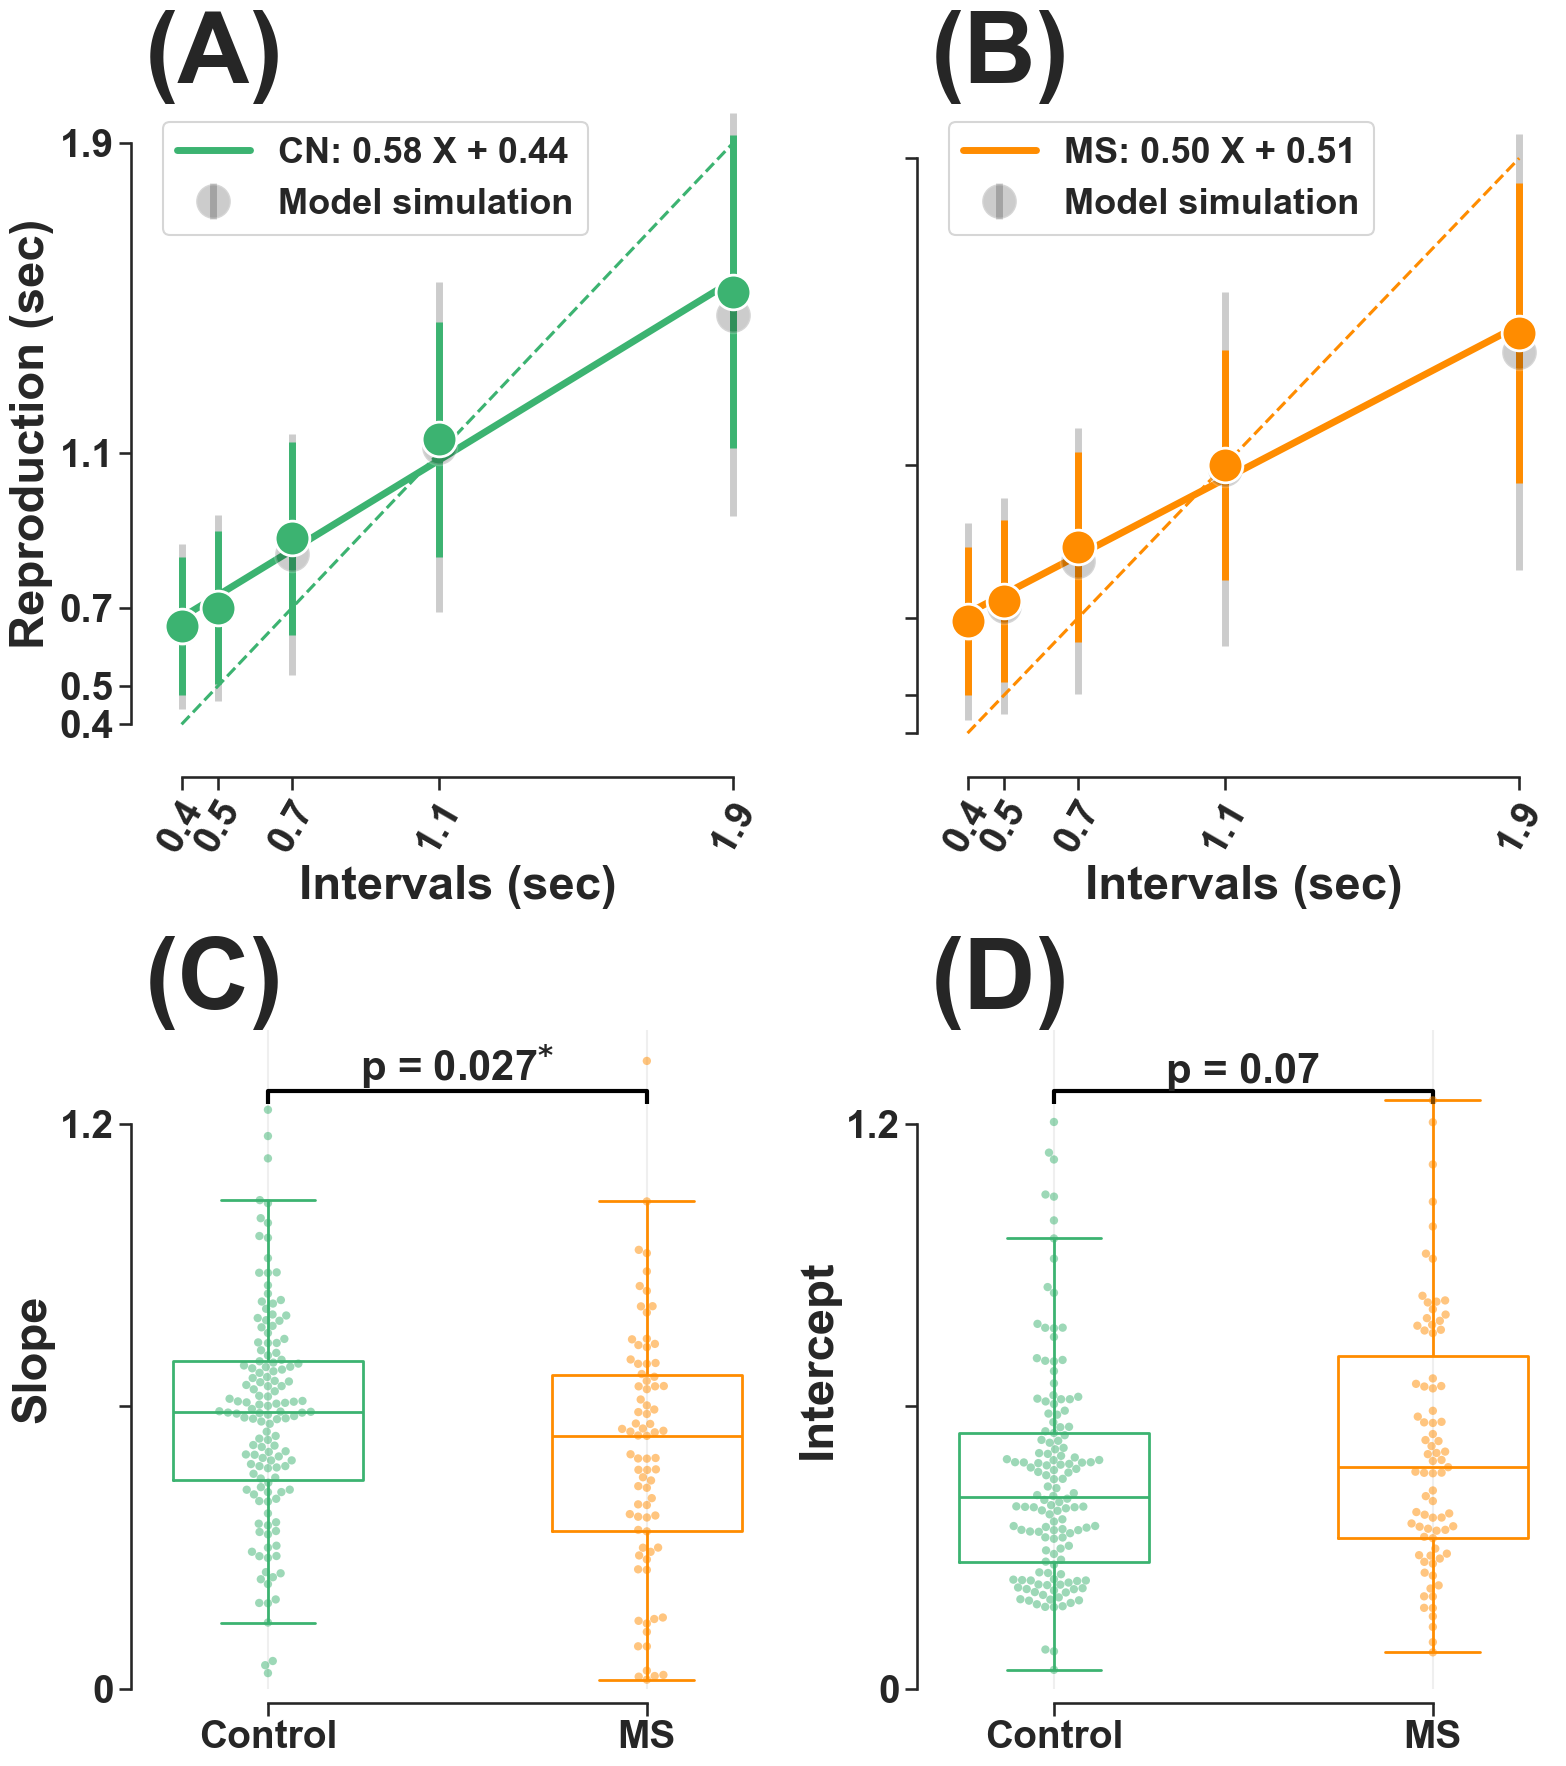

In [3]:
# Per-interval group means come from a bootstrap over subjects (seeded for
# reproducibility); the regression line is fit to those bootstrapped means.
np.random.seed(config.BOOTSTRAP_SEED)
size  = config.BOOTSTRAP_N
x_reg = intervals.reshape((-1, 1))

def bootstrap_group(df_g):
    mu  = df_g.groupby("interval")["cdfMu"].apply(np.array)
    sig = df_g.groupby("interval")["cdfSig"].apply(np.array)
    PSE = np.empty((len(intervals), size)); SIG = np.empty((len(intervals), size))
    slope = np.empty(size); intercept = np.empty(size)
    for pr in range(size):
        for i, itv in enumerate(intervals):
            d = mu.get(itv, np.array([])); s = sig.get(itv, np.array([]))
            d = d[~np.isnan(d)]; s = s[~np.isnan(s)]
            if len(d) > 0:
                idx = np.random.choice(len(d), size=len(d), replace=True)
                PSE[i, pr] = np.mean(d[idx]); SIG[i, pr] = np.mean(s[idx])
            else:
                PSE[i, pr] = np.nan; SIG[i, pr] = np.nan
        reg = LinearRegression().fit(x_reg, PSE[:, pr])
        slope[pr] = reg.coef_[0]; intercept[pr] = reg.intercept_
    return PSE, SIG, slope, intercept

bs_PSEpCN, bs_SIGpCN, bs_RegCN_slope, bs_RegCN_intercept = bootstrap_group(df_subint[df_subint.Group == "Control"])
bs_PSEpMS, bs_SIGpMS, bs_RegMS_slope, bs_RegMS_intercept = bootstrap_group(df_subint[df_subint.Group == "MS"])

_sim = df_sim.set_index("interval").reindex(intervals)
simCN_mean, simCN_std = _sim["CN_mean"].to_numpy(), _sim["CN_std"].to_numpy()
simMS_mean, simMS_std = _sim["MS_mean"].to_numpy(), _sim["MS_std"].to_numpy()

fig, ax = plt.subplots(2, 2, figsize=(16, 18))
x_cont = np.linspace(intervals.min(), intervals.max(), num=1000)

# (A) Control
bs_mean = np.mean(bs_PSEpCN, axis=1); bs_std = np.mean(bs_SIGpCN, axis=1)
y_pred = LinearRegression().fit(x_reg, bs_mean).predict(x_cont.reshape(-1, 1))
ax[0,0].errorbar(intervals, simCN_mean, yerr=simCN_std, marker='o', color='black', ls="None",
                 mec='w', mew=2, ms=25, elinewidth=5, alpha=0.2, label="Model simulation")
ax[0,0].plot(x_cont, y_pred, color=c_CN, lw=5,
             label=f"CN: {np.mean(bs_RegCN_slope):.2f} X + {np.mean(bs_RegCN_intercept):.2f}")
ax[0,0].errorbar(intervals, bs_mean, yerr=bs_std, marker='o', color=c_CN, ls="None",
                 mec='w', mew=2, ms=25, elinewidth=5)
ax[0,0].plot([intervals.min(), intervals.max()], [intervals.min(), intervals.max()], '--', color=c_CN)
ax[0,0].set_title('(A)', fontsize=72, loc='left', fontweight='bold')
ax[0,0].set_xlabel('Intervals (sec)', fontsize=34); ax[0,0].set_ylabel('Reproduction (sec)', fontsize=34)
ax[0,0].set_xticks(intervals); ax[0,0].set_yticks(intervals)
ax[0,0].tick_params(axis='x', rotation=60, labelsize=28); ax[0,0].tick_params(axis='y', labelsize=28)
ax[0,0].set_xlim(0.3, 2); ax[0,0].set_ylim(0.3, 2); ax[0,0].legend(loc="upper left", fontsize=26)

# (B) MS
bs_mean = np.mean(bs_PSEpMS, axis=1); bs_std = np.mean(bs_SIGpMS, axis=1)
y_pred = LinearRegression().fit(x_reg, bs_mean).predict(x_cont.reshape(-1, 1))
ax[0,1].errorbar(intervals, simMS_mean, yerr=simMS_std, marker='o', color='black', ls="None",
                 mec='w', mew=2, ms=25, elinewidth=5, alpha=0.2, label="Model simulation")
ax[0,1].plot(x_cont, y_pred, color=c_MS, lw=5,
             label=f"MS: {np.mean(bs_RegMS_slope):.2f} X + {np.mean(bs_RegMS_intercept):.2f}")
ax[0,1].errorbar(intervals, bs_mean, yerr=bs_std, marker='o', color=c_MS, ls="None",
                 mec='w', mew=2, ms=25, elinewidth=5)
ax[0,1].plot([intervals.min(), intervals.max()], [intervals.min(), intervals.max()], '--', color=c_MS)
ax[0,1].set_title('(B)', fontsize=72, loc='left', fontweight='bold')
ax[0,1].set_xlabel('Intervals (sec)', fontsize=34)
ax[0,1].set_xticks(intervals); ax[0,1].set_yticks(intervals); ax[0,1].set_yticklabels([])
ax[0,1].tick_params(axis='x', rotation=60, labelsize=28)
ax[0,1].set_xlim(0.3, 2); ax[0,1].legend(loc="upper left", fontsize=26)

# (C) Slope, (D) Intercept: unfilled box + swarm + significance bar
plotting.box_swarm(ax[1,0], df_sub, "cdfReg_slope")
ax[1,0].set_title('(C)', fontsize=72, loc='left', fontweight='bold')
ax[1,0].set_xlabel(''); ax[1,0].set_ylabel('Slope', fontsize=34); ax[1,0].grid(axis='x', alpha=0.3)
ax[1,0].set_yticks([0, 0.6, 1.2]); ax[1,0].set_yticklabels([0, None, 1.2], fontsize=28)
ax[1,0].tick_params(axis='x', labelsize=28); ax[1,0].tick_params(axis='y', labelsize=28)
ax[1,0].set_ylim(0, 1.4)
plotting.sig_bar(ax[1,0], 0, 1, 1.27, P["cdfReg_slope"], fontsize=30)

plotting.box_swarm(ax[1,1], df_sub, "cdfReg_int")
ax[1,1].set_title('(D)', fontsize=72, loc='left', fontweight='bold')
ax[1,1].set_xlabel(''); ax[1,1].set_ylabel('Intercept', fontsize=34); ax[1,1].grid(axis='x', alpha=0.3)
ax[1,1].set_yticks([0, 0.6, 1.2]); ax[1,1].set_yticklabels([0, None, 1.2], fontsize=28)
ax[1,1].tick_params(axis='x', labelsize=28); ax[1,1].tick_params(axis='y', labelsize=28)
ax[1,1].set_ylim(0, 1.4)
plotting.sig_bar(ax[1,1], 0, 1, 1.27, P["cdfReg_int"], fontsize=30)

sns.despine(offset=10, trim=True)
plt.tight_layout()
config.FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(config.FIG_DIR / "Figure2.png", dpi=300)
fig.savefig(config.FIG_DIR / "Figure2.pdf", format="pdf", bbox_inches="tight")
plt.show()
